     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00

TECHNICAL REPORT: THE BERNSTEIN-VAZIRANI ALGORITHM

[PROBLEM STATEMENT]
A "Black Box" (Oracle) contains a hidden bitstring 's' of length 10.
In classical computing, to find 's', we must query the box bit-by-bit.
Total Classical Queries: 10

[THE QUANTUM SOLUTION: PHASE KICKBACK]
Quantum computing solves this in exactly 1 query using three physical principles:

1. SUPERPOSITION:
   Applying Hadamard (H) gates to all qubits creates a state where
   all 1024 possible strings exist at once.

2. THE ORACLE & PHASE KICKBACK:
   We use an auxiliary qubit (Ancilla) i

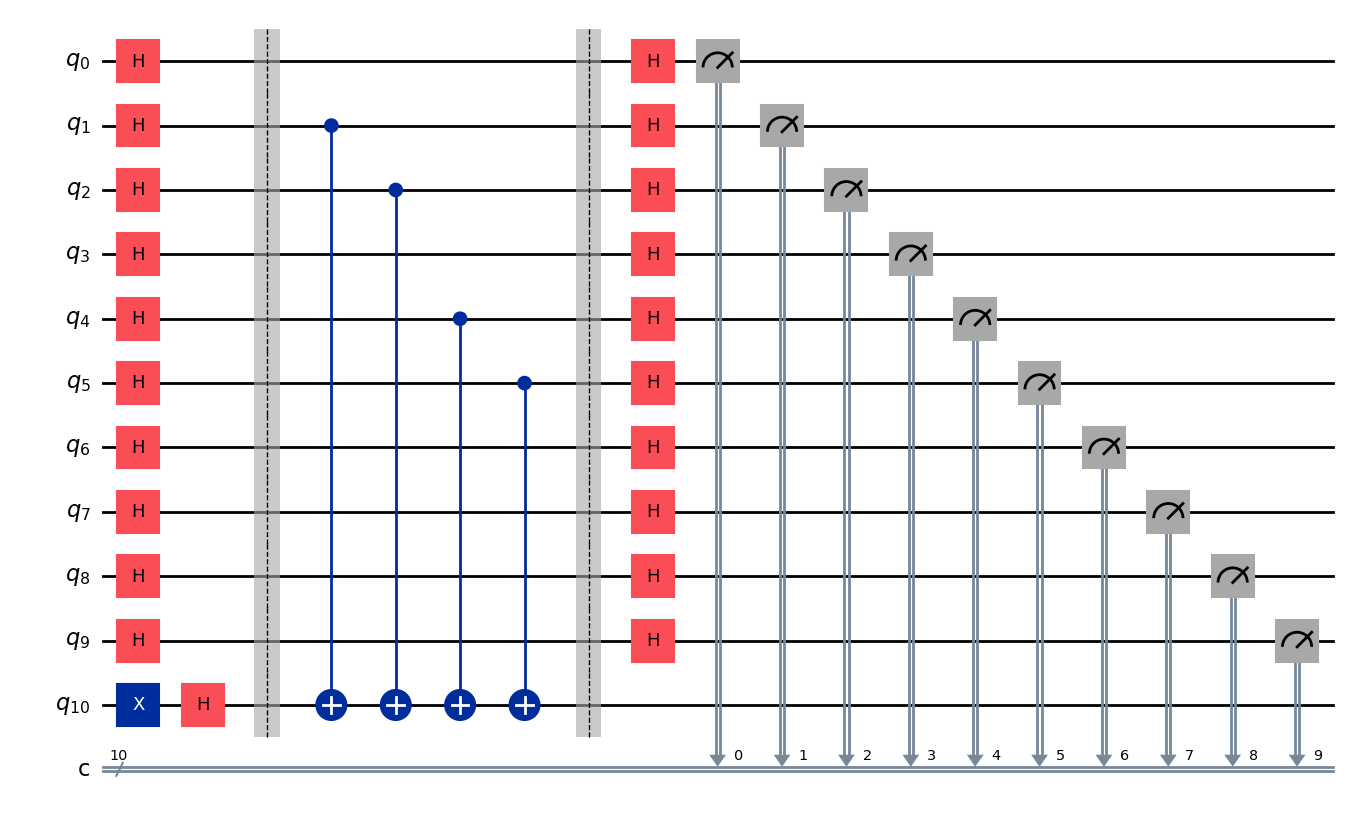

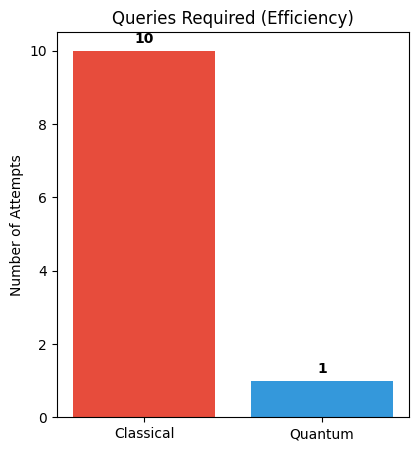


PROJECT COMPLETE: This script proves that Quantum Logic reduces
workload by a factor of 10x for this problem.


In [2]:
# 1. INSTALLATION
!pip install qiskit qiskit-aer pylatexenc -q

import random
import time
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

# 2. CONFIGURATION
BIT_LENGTH = 10
secret_string = ''.join(random.choice('01') for _ in range(BIT_LENGTH))

# 3. THE MATHEMATICAL & PHYSICAL FRAMEWORK
explanation = f"""
{'='*70}
TECHNICAL REPORT: THE BERNSTEIN-VAZIRANI ALGORITHM
{'='*70}

[PROBLEM STATEMENT]
A "Black Box" (Oracle) contains a hidden bitstring 's' of length {BIT_LENGTH}.
In classical computing, to find 's', we must query the box bit-by-bit.
Total Classical Queries: {BIT_LENGTH}

[THE QUANTUM SOLUTION: PHASE KICKBACK]
Quantum computing solves this in exactly 1 query using three physical principles:

1. SUPERPOSITION:
   Applying Hadamard (H) gates to all qubits creates a state where
   all {2**BIT_LENGTH} possible strings exist at once.

2. THE ORACLE & PHASE KICKBACK:
   We use an auxiliary qubit (Ancilla) in the |-> state.
   When the Oracle performs a CNOT operation:

   |x>|->  ---(Oracle)-->  (-1)^(s·x) |x>|->
   The answer is "kicked back" into the phase of the input qubits.

3. CONSTRUCTIVE INTERFERENCE:
   A final set of H-gates causes the incorrect answers to cancel each
   other out (destructive interference) and the correct answer 's'
   to amplify (constructive interference).

[ALGORITHM COMPLEXITY]
- Classical: O(n)
- Quantum:   O(1) <--- This is the "Quantum Speedup"
{'='*70}
"""

print(explanation)

# 4. QUANTUM CIRCUIT CONSTRUCTION
def build_bv_circuit(s):
    n = len(s)
    # Create a circuit with n input qubits + 1 ancilla qubit, and n classical bits
    qc = QuantumCircuit(n + 1, n)

    # Prepare Ancilla qubit in state |->
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()

    # The Oracle: Apply CNOTs based on the secret string
    for i, bit in enumerate(reversed(s)):
        if bit == '1':
            qc.cx(i, n)

    qc.barrier()

    # Final Hadamard gates to trigger constructive interference
    qc.h(range(n))

    # Measure the input qubits
    qc.measure(range(n), range(n))

    return qc

# 5. EXECUTION & BENCHMARKING
print("...Executing Quantum Search...")
circuit = build_bv_circuit(secret_string)
sim = Aer.get_backend('qasm_simulator')

start_time = time.time()
# Execute with shots=1 to prove it only takes a single query
result = sim.run(transpile(circuit, sim), shots=1).result()
quantum_time = time.time() - start_time

quantum_answer = list(result.get_counts().keys())[0]

# 6. FINAL PERFORMANCE OUTPUT
print(f"TARGET SECRET: {secret_string}")
print(f"QUANTUM GUESS: {quantum_answer}")
print("-" * 30)

if secret_string == quantum_answer:
    print("STATUS: SUCCESS! Correct string identified in 1 query.")
else:
    print("STATUS: FAILURE. Check circuit logic.")

# 7. VISUAL COMPARISON CHART
labels = ['Classical', 'Quantum']
queries = [BIT_LENGTH, 1]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
colors = ['#E74C3C', '#3498DB']
plt.bar(labels, queries, color=colors)
plt.title('Queries Required (Efficiency)')
plt.ylabel('Number of Attempts')
for i, v in enumerate(queries):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# 8. CIRCUIT ARCHITECTURE VISUALIZATION
print("\n[CIRCUIT DIAGRAM]")
# Note: In a Jupyter environment, this renders the diagram
display(circuit.draw(output='mpl'))
plt.show()

print("\n" + "="*70)
print("PROJECT COMPLETE: This script proves that Quantum Logic reduces")
print(f"workload by a factor of {BIT_LENGTH}x for this problem.")
print("="*70)